# Polynomial Regression

- Linear regression is all about linear data, but what if the data is non-linear? In that case, we can use polynomial regression to fit a non-linear curve to the data.
- Polynomial regression is a type of linear regression where the relationship between the independent variable and the dependent variable is modeled as an nth degree polynomial.

- Suppose for 1-dimensional data, we have a feature `x` and a target variable `y`. And want to fit 2 degree polynomial to the data, then we can create new features `x^0`, `x^1`, and `x^2` where `x^0` is the bias term (intercept), `x^1` is the original feature, and `x^2` is the square of the original feature.

- The polynomial regression model can be represented as:

    - $ \hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 $

    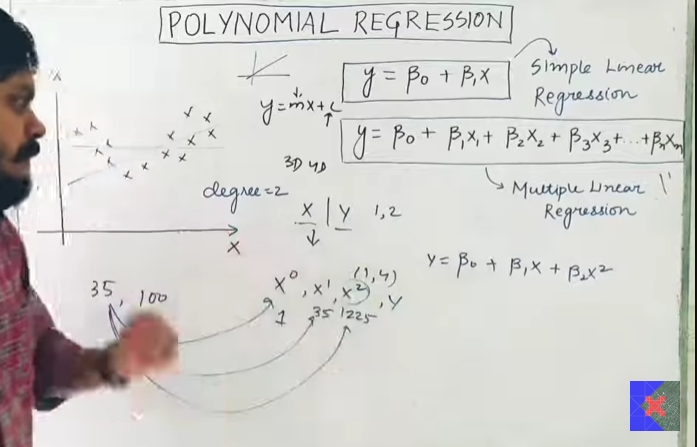

    - In general is we want to fit an nth degree polynomial, then we can create new features `x^0`, `x^1`, `x^2`, ..., `x^n` and the model can be represented as:

        - $ \hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + ... + \beta_n x^n $

## What should be the value of `n`?

- The value of `n` (degree of the polynomial) is a hyperparameter that we need to choose based on the data. We can use techniques like cross-validation to find the best value of `n` for our data.

- If `n` is too small, the model will underfit the data and if `n` is too large, the model will overfit the data. So, we need to find a balance between underfitting and overfitting by choosing the right value of `n`.


### For data with 2-input features:

- Suppose we want to fit a 2 degree polynomial to the data with 2 input features `x1` and `x2`, then we can create new features $x1^0, x1^1, x1^2, x2^0, x2^1, x2^2$ and the model can be represented as:

    - $ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_1^2 + \beta_3 x_2 + \beta_4 x_2^2 $


### Why it is called linear regression? whereas it is fitting a non-linear curve to the data?

- It is called linear regression because the model is linear in terms of the coefficients (parameters) $\beta_0, \beta_1, \beta_2, ... , \beta_n$. And the features are known to us, we need to tune the coefficients to fit the curve to the data. So, the model is linear in terms of the coefficients

- That's why it is called polynomial linear regression.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [ ]:
# Generating synthetic data for regression using the equation y = 0.8x^2 + 0.9x + 2 with some random noise added to it.

X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

# The work of the model is to find the coefficients of the equation which are 0.8 and 0.9 and the intercept which is 2.

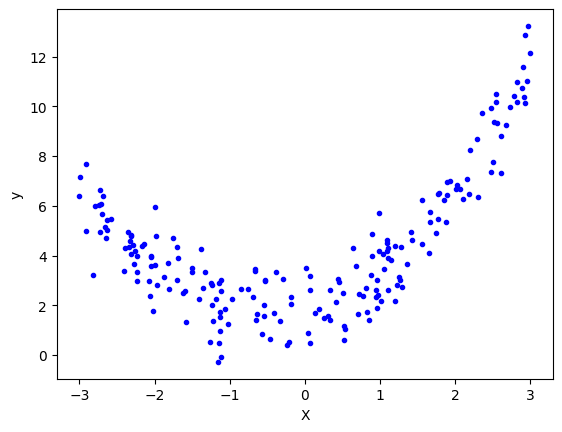

In [3]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [4]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

- Let's see by applying normal linear regression

In [5]:
# Applying linear regression
lr = LinearRegression()

In [6]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.2627905694814999

- The results are poor, oviously the data is non-linear and we are trying to justifying it with a linear model, so the results are not good.

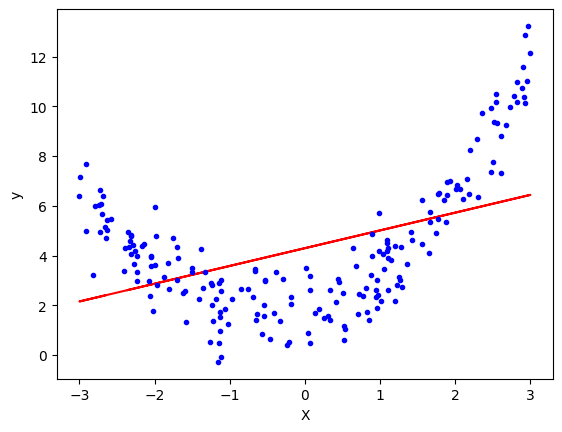

In [8]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

## Applying polynomial regression to the data

- degree 2, so for each feature, we will get 3 features, $x^0, x^1 and x^2$. So the total number of features will be 3.

- Similarly for degree $n$, we will get $n+1$ features for each feature in the original data.

- We do polynomial feature transformation only on the input features, not on the target variable.

- Apply transformation on the training data and test data both


In [ ]:
# Applying Polynomial Linear Regression
# degree 2
poly = PolynomialFeatures(degree=2,include_bias=True) # include_bias=True means that we will get the bias term in the transformed features, which is x^0,



# First we need to transform our data into polynomial features and then we can apply linear regression on it.
X_train_trans = poly.fit_transform(X_train) 
X_test_trans = poly.transform(X_test)

In [10]:
print(X_train[0])
print(X_train_trans[0])

[-2.35737401]
[ 1.         -2.35737401  5.55721221]


- We use the same `LinearRegression` class of scikit-learn to fit the model on the transformed features to apply polynomial regression to the data. The only difference is that we are fitting the model on the transformed features instead of the original features.

In [11]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = lr.predict(X_test_trans)

In [13]:
r2_score(y_test,y_pred)

0.919820833980311

In [14]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.77190937 0.79321691]]
[1.85060045]


In [15]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

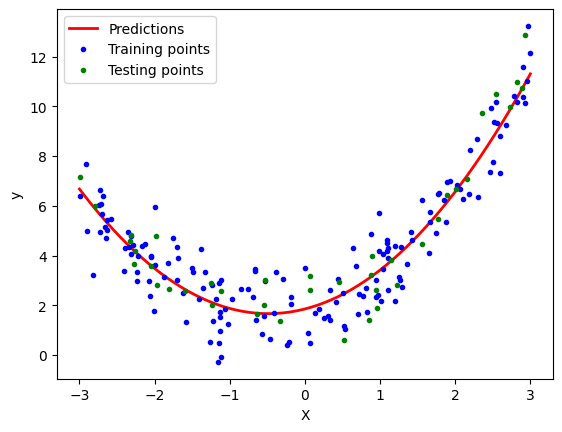

In [16]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# What if we increase the degree of the polynomial?

In [17]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

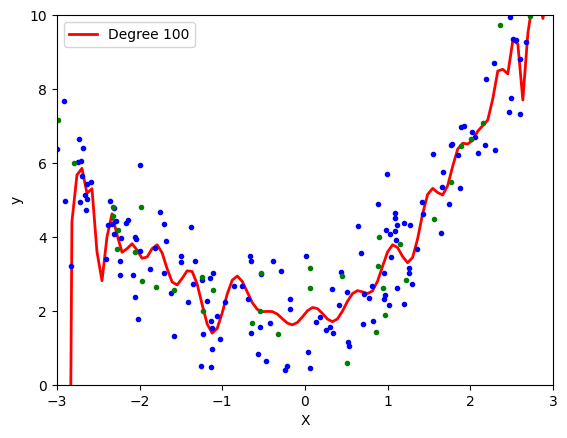

In [23]:
polynomial_regression(100)

- <span style="color:orange">So as we increase the degree, its not capturing the true essence of the data, Ye data k patterns ko ratne ka try kr rha hai (it means its trying to fit the curve to the data points, but its not capturing the true pattern of the data, which is not good, it will lead to overfitting). So, we need to find a balance between underfitting and overfitting by choosing the right value of `n`.
</span>

- The blue points are tranining data, the green points are test data.

    - If we increase the degree of the polynomial, then the model will try to fit the curve to the training data points and will not generalize the pattern of the data

# How to decide the degree of the polynomial?

- We can use techniques like cross-validation to find the best value of `n` for our data. Also there are some curves like learning curves, validation curves, etc. that can help us to find the best value of `n` for our data.

- We will study these curves later in the course


In [20]:
poly.powers_

array([[0],
       [1],
       [2]])

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


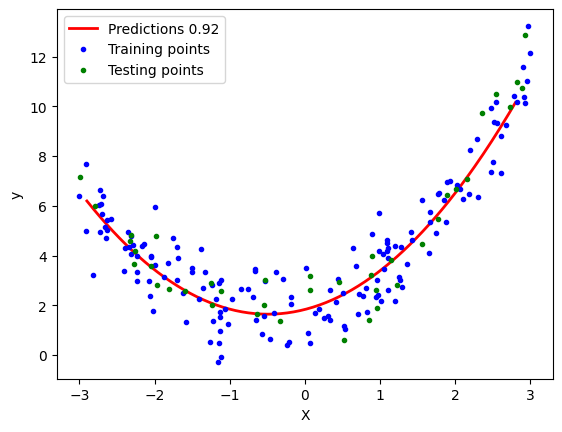

In [24]:
# Applying polynomial linear regression with Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Example with multiple features

In [25]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [26]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

- The data has 2 input features and it looks like:

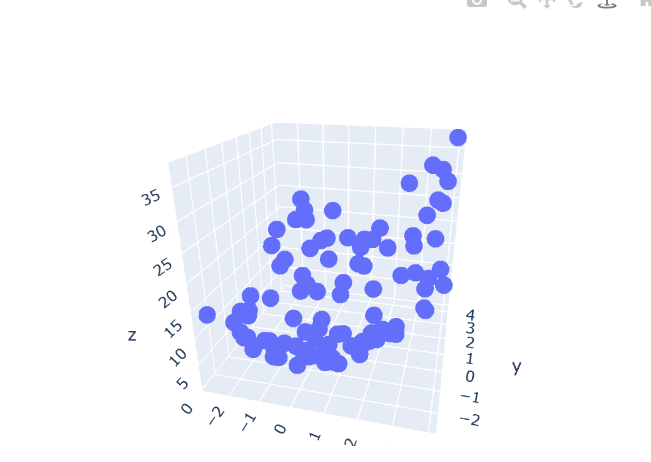

- Applying simple multiple linear regression on this data will not give good results because the data is non-linear.

In [27]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)



In [28]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

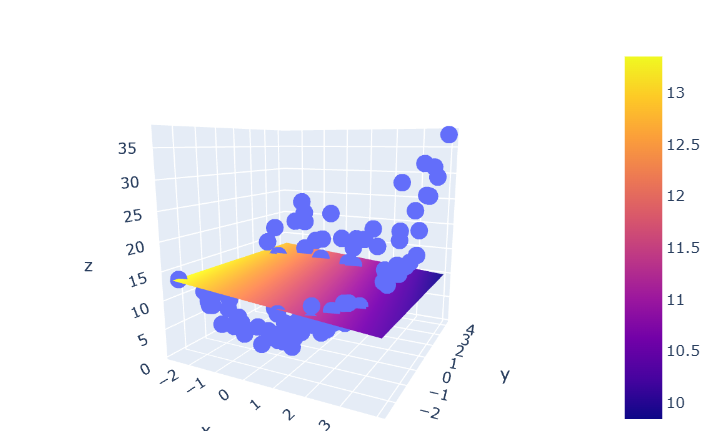

# Applying multiple polynomial linear regression to the data

In [ ]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [37]:
poly = PolynomialFeatures(degree=2)
X_multi_trans = poly.fit_transform(X_multi)

In [ ]:
print("Input", poly.n_features_in_) 
print("Output", poly.n_output_features_)
print("Powers\n", poly.powers_) # it shows the powers of the input features in the output features. 


Input 2
Output 6
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


- For 2 input features and degree 2, we will get 6 output features, which are:

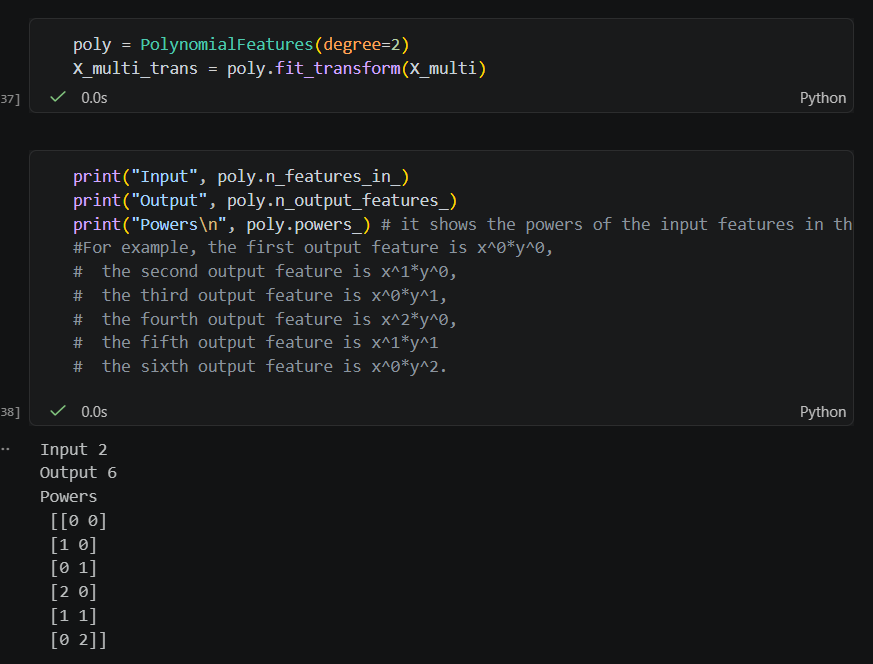

- the first output feature is $x^0*y^0$
-  the second output feature is $x^1*y^0$
-  the third output feature is $x^0*y^1$
-  the fourth output feature is $x^2*y^0$
-  the fifth output feature is $x^1*y^1$
-  the sixth output feature is $x^0*y^2$

In [39]:
X_multi_trans.shape

(100, 6)

In [40]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
X_test_multi = poly.transform(final)

In [43]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [44]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()

- Plot for degree 2

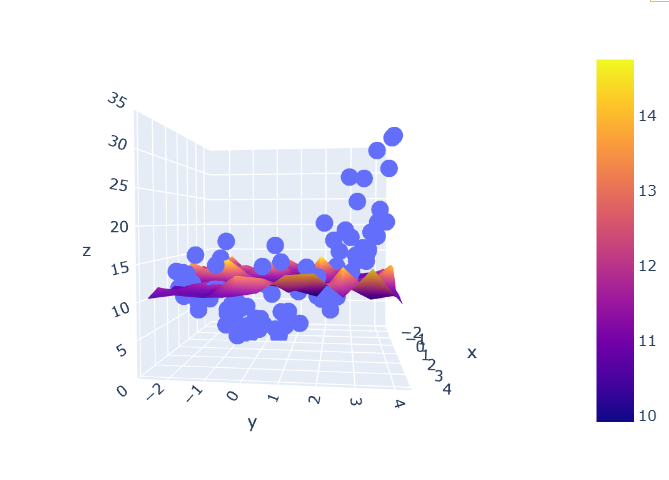